In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib



In [12]:
# 1. Criação do Dataset Sintético (1.0 pt)
# Simulando dados de Telemetria (Aves) + OpenCV (YOLO) + Clima (OpenWeather)
np.random.seed(42)
n_samples = 2000

data = {
    'heart_rate': np.random.normal(300, 50, n_samples),
    'acceleration': np.random.normal(9.8, 2, n_samples),
    'yolo_bird_count': np.random.randint(0, 10, n_samples), # Do oddysey_yolo.py
    'yolo_movement_index': np.random.normal(15000, 5000, n_samples), # Do oddysey_yolo.py
    'pressure_hpa': np.random.normal(1013, 10, n_samples), # Do script.ps1
    'temperature_c': np.random.normal(25, 5, n_samples) # Do script.ps1
}
df = pd.DataFrame(data)

# Criando a variável alvo (Risco de Desastre 0.0 a 1.0)
# Risco aumenta se hr alto, accel alta, birds somem (YOLO), movimento alto (YOLO), pressao cai
df['disaster_risk'] = (
    (df['heart_rate'] / 500) * 0.2 +
    (df['acceleration'] / 20) * 0.2 +
    ((10 - df['yolo_bird_count']) / 10) * 0.2 +
    (df['yolo_movement_index'] / 50000) * 0.2 +
    ((1020 - df['pressure_hpa']) / 50) * 0.2
)
df['disaster_risk'] = np.clip(df['disaster_risk'], 0, 1)



In [13]:
# 2. Preparação e Clusterização K-Means (3.0 pts)
# Usando K-means para achar anomalias comportamentais (Normal vs Pânico)
kmeans = KMeans(n_clusters=2, random_state=42)
df['behavior_cluster'] = kmeans.fit_predict(df[['heart_rate', 'acceleration', 'yolo_movement_index']])



In [14]:
# 3. Feature Selection
# 3. Feature Selection
# Removemos o cluster para que o XGBoost dependa apenas da telemetria bruta
X = df.drop(columns=['disaster_risk', 'behavior_cluster'])
y = df['disaster_risk']
print("começou seleçao de features")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_regression, k=4)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()]
print(f"Features selecionadas: {selected_features}")

X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.3, random_state=42)



começou seleçao de features
Features selecionadas: Index(['acceleration', 'yolo_bird_count', 'yolo_movement_index',
       'pressure_hpa'],
      dtype='object')


In [15]:
# 4. Treinamento: MLP e XGBoost
print("Treinando MLP Regressor...")
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)



Treinando MLP Regressor...


,loss,'squared_error'
,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


In [16]:
print("Treinando XGBoost Regressor...")
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, seed=42)
xg_reg.fit(X_train, y_train)



Treinando XGBoost Regressor...


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred_mlp = mlp.predict(X_test)
mse = mean_squared_error(y_test, y_pred_mlp)
r2 = r2_score(y_test, y_pred_mlp)
print(f"MLP - MSE: {mse:.4f}, R2: {r2:.4f}") # ate tentei fazer um scaler pra melhora mas piorou

MLP - MSE: 0.6943, R2: -117.7107


In [18]:
# 5. Avaliação e Métricas (1.0 pt)
y_pred_xgb = xg_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - MSE: {mse:.4f}, R2: {r2:.4f}")



XGBoost - MSE: 0.0006, R2: 0.8993


Gráfico salvo como avaliacao_modelo.png


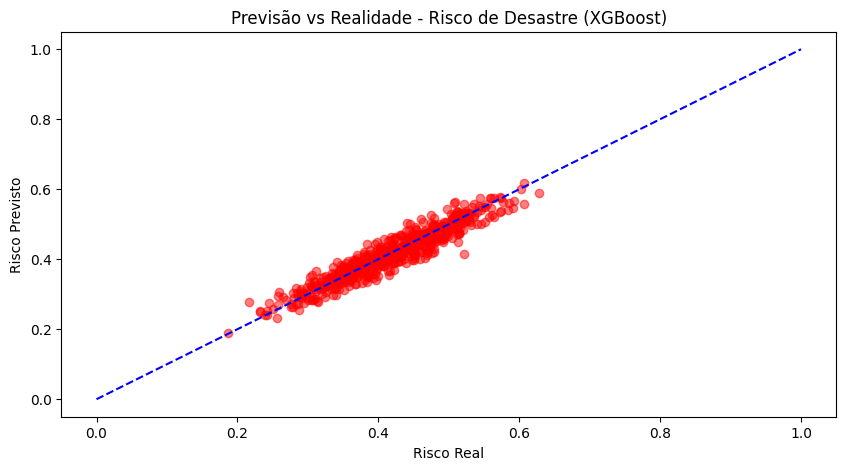

In [19]:
# 6. Avaliação Visual (1.0 pt)
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='red')
plt.plot([0, 1], [0, 1], '--', color='blue')
plt.title('Previsão vs Realidade - Risco de Desastre (XGBoost)')
plt.xlabel('Risco Real')
plt.ylabel('Risco Previsto')
plt.savefig('avaliacao_modelo.png')
print("Gráfico salvo como avaliacao_modelo.png")



In [20]:
# Salvando o modelo treinado para a API
joblib.dump(xg_reg, 'xgboost_ioa.pkl')
joblib.dump(list(selected_features), 'features.pkl')

['features.pkl']